# Step 5: Unsupervised Models (F5)

Abraham Tedla (wqp7qy@virginia.edu)  
DS 5001  
April 2026

Apply PCA, LDA, and word2vec to the corpus. Produce tables required by the project spec.

# Set Up

In [38]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()
%matplotlib inline

In [40]:
output_dir = 'output'

# Load Data

In [41]:
TFIDF = pd.read_csv(os.path.join(output_dir, 'TFIDF.csv'), index_col='book_id')
VOCAB = pd.read_csv(os.path.join(output_dir, 'VOCAB.csv'), index_col='term_str')
TOKEN = pd.read_csv(os.path.join(output_dir, 'TOKEN.csv'))
LIBRARY = pd.read_csv(os.path.join(output_dir, 'LIBRARY.csv'), index_col='book_id')

In [42]:
print(f'TFIDF: {TFIDF.shape}')
print(f'VOCAB: {VOCAB.shape}')
print(f'TOKEN: {TOKEN.shape}')
print(f'LIBRARY: {LIBRARY.shape}')

TFIDF: (12, 25122)
VOCAB: (25122, 21)
TOKEN: (871168, 24)
LIBRARY: (12, 7)


# PCA (Principal Component Analysis)

Apply PCA to the TFIDF document-term matrix. Produces:
- DOC_COMPONENTS: documents × components
- LOADINGS: components × terms (added to VOCAB)

In [43]:
from sklearn.decomposition import PCA

In [44]:
n_components = 10
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(TFIDF.values)

In [45]:
pc_cols = [f'PC{i}' for i in range(n_components)]

DOC_COMPONENTS = pd.DataFrame(pca_result, index=TFIDF.index, columns=pc_cols)
DOC_COMPONENTS = DOC_COMPONENTS.join(LIBRARY[['title', 'genre']])
DOC_COMPONENTS

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,title,genre
book_id,,,,,,,,,,,,
35,-0.002452,-0.000842,-0.000283,-0.000450,0.000650,0.000854,0.002734,-0.000746,0.004509,-0.005326,The Time Machine,SciFi
36,-0.002525,-0.001056,-0.000542,-0.001218,-0.000180,0.000477,0.002330,-0.000782,0.004959,0.005389,The War of the Worlds,SciFi
42,-0.003497,0.017098,0.001166,0.000049,-0.000790,-0.000867,-0.001298,0.000165,-0.000351,0.000047,Dr. Jekyll and Mr. Hyde,Gothic
62,-0.002919,-0.002971,-0.003734,-0.009315,-0.009193,-0.003627,-0.003147,0.000273,-0.001048,-0.000393,A Princess of Mars,SciFi
84,-0.002218,-0.000725,-0.000227,-0.000271,0.000481,0.000773,0.002096,-0.000516,0.001895,-0.000523,Frankenstein,Gothic
139,-0.002583,-0.001059,-0.000537,-0.000549,0.000783,0.001407,0.006248,0.007403,-0.002935,0.000252,The Lost World,SciFi
159,-0.002996,-0.002262,-0.001161,-0.002428,0.011041,-0.007481,-0.003443,0.000307,-0.000706,0.000070,The Island of Doctor Moreau,SciFi
164,-0.002860,-0.001728,-0.000890,-0.001515,0.002941,0.011246,-0.005969,0.000350,-0.000835,0.000093,Twenty Thousand Leagues Under the Sea,SciFi
174,-0.003075,-0.002072,-0.007497,0.012312,-0.003410,-0.002087,-0.002312,0.000187,-0.000471,0.000062,The Picture of Dorian Gray,Gothic


## Explained Variance

In [46]:
explained = pd.Series(pca.explained_variance_ratio_, index=pc_cols)
explained

PC0    0.367964
PC1    0.120259
PC2    0.097632
PC3    0.095077
PC4    0.086343
PC5    0.075636
PC6    0.054948
PC7    0.038225
PC8    0.028857
PC9    0.020993
dtype: float64

<Axes: title={'center': 'PCA Explained Variance Ratio'}>

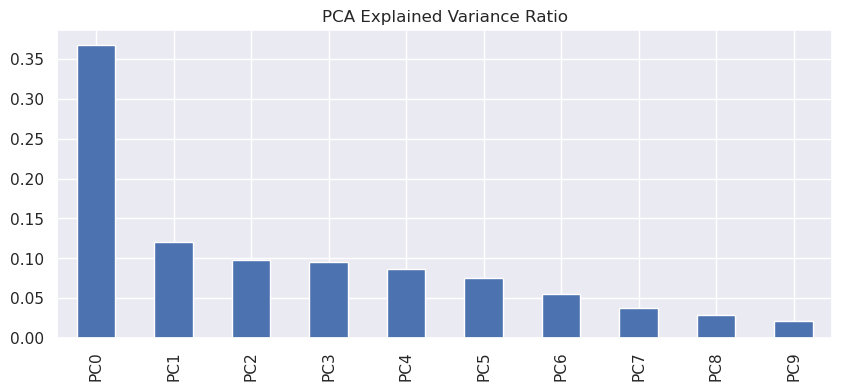

In [47]:
explained.plot.bar(figsize=(10, 4), title='PCA Explained Variance Ratio')

In [48]:
print(f'Cumulative variance explained by {n_components} components: {explained.sum():.3f}')

Cumulative variance explained by 10 components: 0.986


## PCA Loadings (Components × Terms)

In [49]:
LOADINGS = pd.DataFrame(pca.components_, index=pc_cols, columns=TFIDF.columns).T
LOADINGS.index.name = 'term_str'
LOADINGS.head(10)

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_str,,,,,,,,,,
a,-2.267151e-15,6.244470e-16,-6.882782e-17,-4.087548e-16,1.165494e-15,1.973190e-15,5.670564e-16,-2.707338e-16,8.579395e-16,7.870192e-16
aback,-3.800441e-05,-4.554572e-05,-1.549859e-05,-2.541670e-05,5.049463e-05,9.107461e-05,5.268826e-04,-1.029041e-03,-8.650614e-04,7.199630e-05
abaft,-7.600882e-05,-9.109145e-05,-3.099717e-05,-5.083339e-05,1.009893e-04,1.821492e-04,1.053765e-03,-2.058082e-03,-1.730123e-03,1.439926e-04
abaht,-6.023345e-05,-2.392940e-04,1.095754e-03,2.998467e-04,-2.709327e-04,-1.817374e-04,-2.952265e-04,6.075134e-05,-1.322385e-04,1.593597e-05
abandon,5.522109e-04,-2.085804e-04,-5.141113e-05,1.583613e-04,1.545545e-04,8.960423e-04,-1.041370e-04,1.519689e-04,3.830104e-04,-1.169391e-03
abandoned,1.876116e-04,-5.167897e-04,2.538732e-04,-3.366239e-04,8.721519e-04,1.035566e-03,-2.954159e-05,3.592326e-04,1.776821e-03,2.333054e-03
abandoning,-2.586751e-04,-5.476179e-04,-4.830832e-04,-1.096868e-03,9.200817e-04,5.622124e-04,-1.903339e-03,8.795948e-05,3.572742e-04,1.668915e-03
abandonment,-6.023345e-05,-2.392940e-04,1.095754e-03,2.998467e-04,-2.709327e-04,-1.817374e-04,-2.952265e-04,6.075134e-05,-1.322385e-04,1.593597e-05
abart,-1.027492e-04,-1.314726e-04,-8.319986e-05,-1.917694e-04,-3.128983e-05,9.437975e-05,6.350838e-04,-3.062620e-04,2.573290e-03,3.844335e-03


In [50]:
# Top positive and negative loadings for PC0
print('--- PC0 top positive ---')
print(LOADINGS['PC0'].sort_values(ascending=False).head(10).to_string())
print('\n--- PC0 top negative ---')
print(LOADINGS['PC0'].sort_values().head(10).to_string())

--- PC0 top positive ---
term_str
manfred      0.669286
matilda      0.362352
theodore     0.292013
hippolita    0.277093
isabella     0.186722
thy          0.164192
jerome       0.149204
frederic     0.140678
bianca       0.138546
princess     0.130490

--- PC0 top negative ---
term_str
utterson     -0.043973
dorian       -0.039361
montgomery   -0.034718
jekyll       -0.032560
heathcliff   -0.028551
nemo         -0.026025
linton       -0.024334
moreau       -0.023826
challenger   -0.019440
conseil      -0.019298


In [51]:
print('--- PC1 top positive ---')
print(LOADINGS['PC1'].sort_values(ascending=False).head(10).to_string())
print('\n--- PC1 top negative ---')
print(LOADINGS['PC1'].sort_values().head(10).to_string())

--- PC1 top positive ---
term_str
utterson    0.657856
jekyll      0.487115
hyde        0.277259
poole       0.220740
lawyer      0.201155
lanyon      0.160698
enfield     0.095414
cabinet     0.057266
edward      0.043683
butler      0.042887

--- PC1 top negative ---
term_str
heathcliff   -0.113425
linton       -0.096675
dorian       -0.081144
montgomery   -0.080194
catherine    -0.065536
dejah        -0.059360
thoris       -0.059022
moreau       -0.055035
nemo         -0.048103
hareton      -0.042834


## Add Loadings to VOCAB

In [52]:
for col in pc_cols:
    VOCAB[col] = LOADINGS[col]
VOCAB[pc_cols].head(10)

,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
term_str,,,,,,,,,,
the,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
and,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
of,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
i,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
to,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
a,-2.267151e-15,6.244470e-16,-6.882782e-17,-4.087548e-16,1.165494e-15,1.973190e-15,5.670564e-16,-2.707338e-16,8.579395e-16,7.870192e-16
in,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
that,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00
was,0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00


## PCA Scatter: PC0 vs PC1

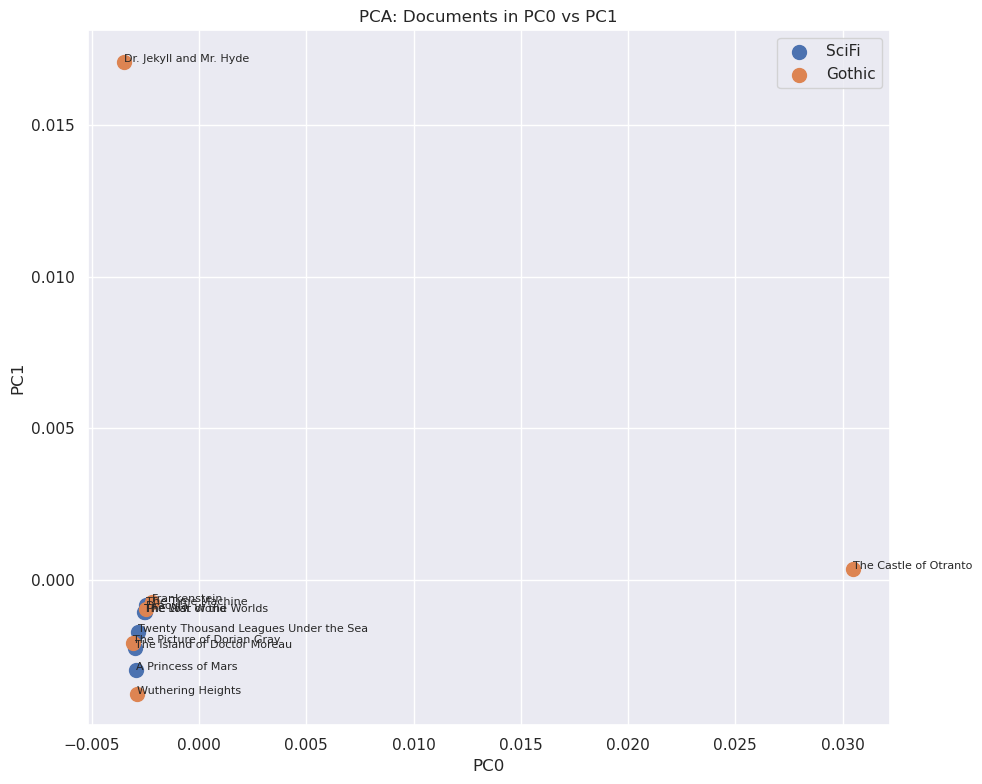

In [53]:
fig, ax = plt.subplots(figsize=(10, 8))
for genre in DOC_COMPONENTS['genre'].unique():
    subset = DOC_COMPONENTS[DOC_COMPONENTS['genre'] == genre]
    ax.scatter(subset['PC0'], subset['PC1'], label=genre, s=100)
    for _, row in subset.iterrows():
        ax.annotate(row['title'], (row['PC0'], row['PC1']), fontsize=8, ha='left')
ax.set_xlabel('PC0')
ax.set_ylabel('PC1')
ax.legend()
ax.set_title('PCA: Documents in PC0 vs PC1')
plt.tight_layout()

# LDA (Latent Dirichlet Allocation)

Topic model on the raw count matrix. Produces:
- DOC_TOPICS: documents × topic concentrations
- TOPIC_TERMS: topics × term weights

In [54]:
from sklearn.decomposition import LatentDirichletAllocation

In [55]:
# Build raw count matrix (LDA needs counts, not TFIDF)
OHCO = ['book_id', 'chapter', 'para_num', 'sent_num']
BOW = TOKEN.groupby(['book_id', 'term_str']).size().rename('n').reset_index()
DTCM = BOW.pivot_table(index='book_id', columns='term_str', values='n', fill_value=0)

In [56]:
n_topics = 10
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
lda_result = lda.fit_transform(DTCM.values)

In [57]:
topic_cols = [f'T{i}' for i in range(n_topics)]

DOC_TOPICS = pd.DataFrame(lda_result, index=DTCM.index, columns=topic_cols)
DOC_TOPICS = DOC_TOPICS.join(LIBRARY[['title', 'genre']])
DOC_TOPICS

,T0,T1,T2,T3,T4,T5,T6,T7,T8,T9,title,genre
book_id,,,,,,,,,,,,
35,3.080715e-06,9.924052e-01,7.570181e-03,3.080715e-06,3.080715e-06,3.080715e-06,3.080715e-06,3.080715e-06,3.080715e-06,3.080715e-06,The Time Machine,SciFi
36,1.664863e-06,9.999763e-01,1.038164e-05,1.664863e-06,1.664863e-06,1.664863e-06,1.664863e-06,1.664863e-06,1.664863e-06,1.664863e-06,The War of the Worlds,SciFi
42,3.926805e-06,2.892928e-01,7.106758e-01,3.926805e-06,3.926805e-06,3.926805e-06,3.926805e-06,3.926805e-06,3.926805e-06,3.926805e-06,Dr. Jekyll and Mr. Hyde,Gothic
62,1.517842e-06,9.894307e-01,1.055720e-02,1.517842e-06,1.517842e-06,1.517842e-06,1.517842e-06,1.517842e-06,1.517842e-06,1.517842e-06,A Princess of Mars,SciFi
84,1.335167e-06,2.330724e-01,7.669169e-01,1.335167e-06,1.335167e-06,1.335167e-06,1.335167e-06,1.335167e-06,1.335167e-06,1.335167e-06,Frankenstein,Gothic
139,1.333014e-06,9.089174e-01,9.107197e-02,1.333014e-06,1.333014e-06,1.333014e-06,1.333014e-06,1.333014e-06,1.333014e-06,1.333014e-06,The Lost World,SciFi
159,2.323690e-06,9.811153e-01,1.886608e-02,2.323690e-06,2.323690e-06,2.323690e-06,2.323690e-06,2.323690e-06,2.323690e-06,2.323690e-06,The Island of Doctor Moreau,SciFi
164,9.719024e-07,9.999913e-01,9.721674e-07,9.719024e-07,9.719024e-07,9.719024e-07,9.719024e-07,9.719024e-07,9.719024e-07,9.719024e-07,Twenty Thousand Leagues Under the Sea,SciFi
174,1.264910e-06,2.966224e-04,9.996933e-01,1.264910e-06,1.264910e-06,1.264910e-06,1.264910e-06,1.264910e-06,1.264910e-06,1.264910e-06,The Picture of Dorian Gray,Gothic


## Topic-Term Weights

In [58]:
TOPIC_TERMS = pd.DataFrame(lda.components_, index=topic_cols, columns=DTCM.columns)
# Normalize rows to get term probabilities per topic
TOPIC_TERMS = TOPIC_TERMS.div(TOPIC_TERMS.sum(axis=1), axis=0)
TOPIC_TERMS.iloc[:, :10]

term_str,a,aback,abaft,abaht,abandon,abandoned,abandoning,abandonment,abart,abasement
T0,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05
T1,0.022891,2.467496e-07,2.467484e-07,2.467436e-07,0.000016,0.000058,1.505136e-05,2.467436e-07,2.714179e-06,2.467496e-07
T2,0.018835,2.335881e-06,4.459415e-06,2.335886e-06,0.000014,0.000020,2.123536e-07,2.335886e-06,2.123533e-07,2.335881e-06
T3,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05
T4,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05
T5,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05
T6,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05
T7,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05
T8,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05
T9,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,0.000040,0.000040,3.980575e-05,3.980575e-05,3.980575e-05,3.980575e-05


In [59]:
# Top terms per topic
for topic in topic_cols:
    top = TOPIC_TERMS.loc[topic].sort_values(ascending=False).head(10)
    print(f'\n--- {topic} ---')
    print(top.to_string())


--- T0 ---
term_str
delivers       0.00004
housemaid      0.00004
cosily         0.00004
dwarfish       0.00004
partakes       0.00004
unobtrusive    0.00004
dethroned      0.00004
familiars      0.00004
payable        0.00004
pecuniary      0.00004

--- T1 ---
term_str
the     0.073549
of      0.037719
and     0.032651
i       0.026236
a       0.022891
to      0.022541
in      0.015664
was     0.014015
that    0.012162
it      0.011834

--- T2 ---
term_str
the     0.046220
and     0.035502
i       0.029958
to      0.028584
of      0.023948
a       0.018835
he      0.016390
in      0.014283
that    0.014032
it      0.012663

--- T3 ---
term_str
delivers       0.00004
housemaid      0.00004
cosily         0.00004
dwarfish       0.00004
partakes       0.00004
unobtrusive    0.00004
dethroned      0.00004
familiars      0.00004
payable        0.00004
pecuniary      0.00004

--- T4 ---
term_str
delivers       0.00004
housemaid      0.00004
cosily         0.00004
dwarfish       0.00004
par

## Doc-Topic Heatmap

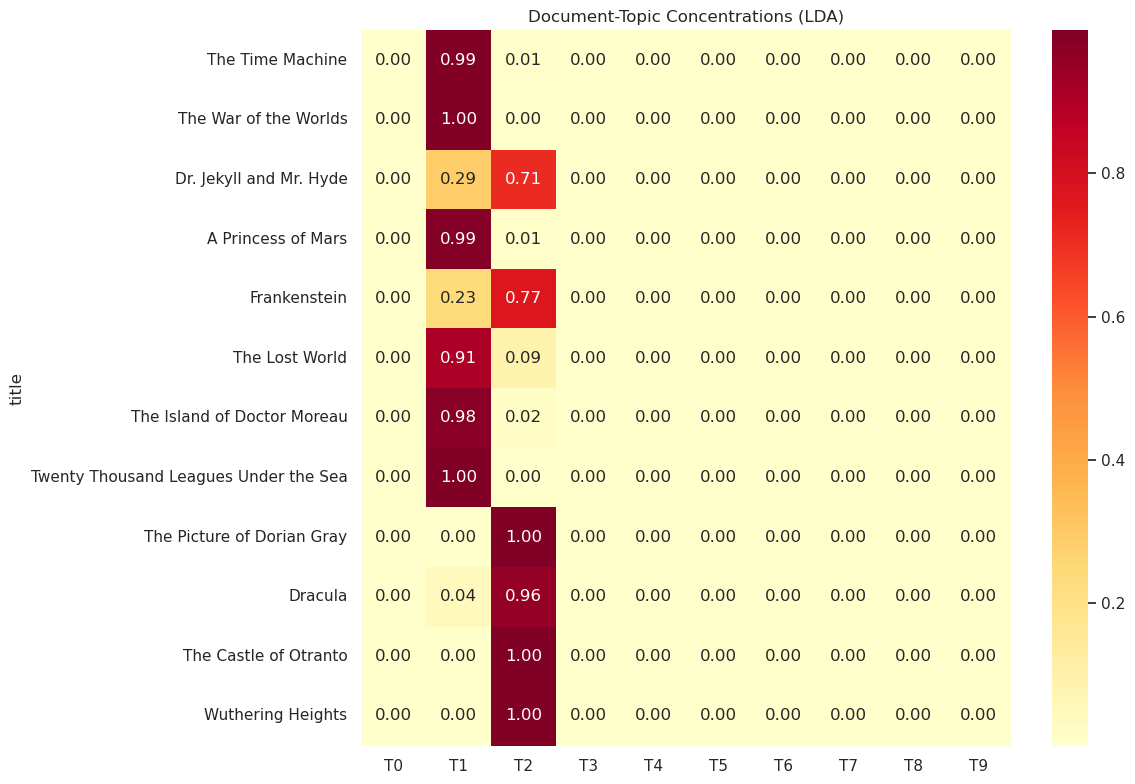

In [60]:
heatmap_data = DOC_TOPICS[topic_cols].copy()
heatmap_data.index = DOC_TOPICS['title']

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Document-Topic Concentrations (LDA)')
plt.tight_layout()

# Word2Vec (Word Embeddings)

Train word2vec on the corpus sentences. Produces term embeddings.

In [61]:
from gensim.models import Word2Vec

In [62]:
# Build sentences as lists of term_str
sentences = (
    TOKEN.groupby(['book_id', 'chapter', 'para_num', 'sent_num'])['term_str']
    .apply(list)
    .tolist()
)
print(f'Number of sentences for word2vec: {len(sentences):,}')

Number of sentences for word2vec: 48,638


In [63]:
w2v_dim = 50
w2v = Word2Vec(sentences, vector_size=w2v_dim, window=5, min_count=5, workers=1, seed=42, epochs=20)
print(f'Vocabulary size in word2vec: {len(w2v.wv)}')

Vocabulary size in word2vec: 9328


In [64]:
# Build embeddings table
w2v_cols = [f'w2v_{i}' for i in range(w2v_dim)]
w2v_terms = list(w2v.wv.index_to_key)
w2v_vectors = [w2v.wv[t] for t in w2v_terms]

WORD2VEC = pd.DataFrame(w2v_vectors, index=w2v_terms, columns=w2v_cols)
WORD2VEC.index.name = 'term_str'
print(f'WORD2VEC shape: {WORD2VEC.shape}')
WORD2VEC.head(10)

WORD2VEC shape: (9328, 50)


,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_40,w2v_41,w2v_42,w2v_43,w2v_44,w2v_45,w2v_46,w2v_47,w2v_48,w2v_49
term_str,,,,,,,,,,,,,,,,,,,,,
the,-1.282553,0.056940,0.245592,0.156248,0.670106,0.029233,-0.842236,-0.716115,-0.574864,-0.313651,...,-0.569342,1.570044,0.106489,0.782007,-0.743340,-0.072816,-1.214531,0.679188,0.530729,1.010277
and,-0.246319,0.449773,-0.831997,0.233689,0.966587,-0.256901,0.414106,1.665631,0.346537,0.529606,...,0.973954,1.074704,0.222817,0.996366,0.553882,-0.637133,0.028697,-0.640135,0.377369,-1.107686
of,-0.123118,0.328030,-0.219267,-1.280812,1.958726,0.154833,0.438783,-0.907255,-0.433863,-0.060682,...,1.190400,-1.974590,0.820080,0.169485,-1.021482,1.207925,0.351801,-0.318330,1.813048,-1.110147
i,1.226339,-1.144693,2.617284,-2.320563,-0.343282,-1.180104,-1.990819,1.550692,2.210542,3.245146,...,2.835894,1.199038,-0.788105,3.102920,2.428525,-1.218361,-2.493718,-0.227634,0.416117,0.032091
to,1.321969,2.762945,-1.129697,0.112912,-1.434882,-1.393005,0.386242,2.549685,1.012353,0.061766,...,-0.955507,0.918902,-1.644979,-0.150848,2.201542,-2.646555,-2.157879,-1.882173,0.798161,-2.119972
a,-1.537608,0.335674,0.855373,-0.707887,-0.509291,-0.888175,-2.887521,-0.923610,-0.668183,-1.416307,...,-1.314783,0.078317,0.414985,-1.656080,-0.244752,-0.663935,-0.499156,-1.593317,1.908752,1.248891
in,-2.587581,2.274975,1.106769,0.870492,1.659264,0.650830,-0.438148,1.194952,-0.792556,-1.339332,...,0.189550,-0.810801,-0.144949,-0.045852,0.123504,0.931497,-1.192856,0.259689,-0.266732,-1.052260
that,-0.740953,-1.165449,-1.071554,-0.298650,0.424950,-0.699009,-0.858054,0.118160,2.550835,0.948092,...,2.404166,-0.083371,1.409321,1.230513,0.562028,-0.606340,-2.515780,-0.182612,1.549549,-0.128738
was,1.240251,0.742449,2.221180,0.150254,-3.040546,-0.217636,-1.565117,-0.396636,-1.851664,-0.210617,...,0.912935,-1.715797,0.573444,0.171394,-0.458061,-0.300641,0.789424,2.274780,0.032913,1.438473


## Similar Words

In [65]:
w2v.wv.most_similar('death', topn=10)

[('life', 0.6671730279922485),
 ('passion', 0.6456021070480347),
 ('soul', 0.6382957100868225),
 ('memory', 0.6311495900154114),
 ('child', 0.5917701721191406),
 ('misery', 0.5909198522567749),
 ('cause', 0.5897042751312256),
 ('torture', 0.5876022577285767),
 ('sorrow', 0.5768222808837891),
 ('brain', 0.5765275359153748)]

In [66]:
w2v.wv.most_similar('monster', topn=10)

[('threat', 0.6698944568634033),
 ('creature', 0.6243730187416077),
 ('warrior', 0.5681268572807312),
 ('dæmon', 0.5559415221214294),
 ('outbreak', 0.5540958642959595),
 ('picture', 0.5466575026512146),
 ('blow', 0.5337662696838379),
 ('portrait', 0.5327354073524475),
 ('iguanodon', 0.5300775170326233),
 ('animal', 0.5260790586471558)]

In [67]:
w2v.wv.most_similar('science', topn=10)

[('natural', 0.7878953814506531),
 ('knowledge', 0.7279220819473267),
 ('scientific', 0.7031351923942566),
 ('history', 0.6762203574180603),
 ('modern', 0.6760637760162354),
 ('conditions', 0.6734625697135925),
 ('system', 0.6720507740974426),
 ('future', 0.6650237441062927),
 ('differed', 0.6565326452255249),
 ('community', 0.6552619934082031)]

In [68]:
w2v.wv.most_similar('love', topn=10)

[('pity', 0.7324805855751038),
 ('loved', 0.7254773378372192),
 ('hate', 0.6739393472671509),
 ('affection', 0.6617299914360046),
 ('trust', 0.6601497530937195),
 ('lover', 0.6539781093597412),
 ('play', 0.6507670879364014),
 ('gratitude', 0.6506142020225525),
 ('happiness', 0.6488966941833496),
 ('cousin', 0.6286604404449463)]

# Save All Outputs

In [69]:
DOC_COMPONENTS.to_csv(os.path.join(output_dir, 'DOC_COMPONENTS.csv'))
print('Saved DOC_COMPONENTS.csv')

Saved DOC_COMPONENTS.csv


In [70]:
LOADINGS.to_csv(os.path.join(output_dir, 'LOADINGS.csv'))
print('Saved LOADINGS.csv')

Saved LOADINGS.csv


In [71]:
DOC_TOPICS.to_csv(os.path.join(output_dir, 'DOC_TOPICS.csv'))
print('Saved DOC_TOPICS.csv')

Saved DOC_TOPICS.csv


In [72]:
TOPIC_TERMS.to_csv(os.path.join(output_dir, 'TOPIC_TERMS.csv'))
print('Saved TOPIC_TERMS.csv')

Saved TOPIC_TERMS.csv


In [73]:
WORD2VEC.to_csv(os.path.join(output_dir, 'WORD2VEC.csv'))
print('Saved WORD2VEC.csv')

Saved WORD2VEC.csv


In [74]:
VOCAB.to_csv(os.path.join(output_dir, 'VOCAB.csv'))
print(f'Saved VOCAB.csv (with PCA loadings)')

Saved VOCAB.csv (with PCA loadings)


# Summary

- PCA on TFIDF matrix → `DOC_COMPONENTS.csv` (docs × 10 PCs), `LOADINGS.csv` (terms × PCs), loadings added to VOCAB.
- LDA on count matrix → `DOC_TOPICS.csv` (docs × 10 topics), `TOPIC_TERMS.csv` (topics × term weights).
- word2vec (50-dim) → `WORD2VEC.csv` (terms × embeddings).

**Next:** Step 6 — Exploration & Visualization notebook.